# HelioGuard: Calibrated Space-Weather Risk Scoring for Satellite Anomalies

**Author:** Nikola Kolev
**Course:** Machine Learning, SoftUni 2026
**Repository:** https://github.com/niki7o/HelioGuard

---

## Abstract

Solar storms drive a measurable fraction of geostationary spacecraft
anomalies through surface charging (ESD), internal and deep-dielectric
charging (ECEMP), and single-event upsets from energetic particles
(SEU). The published literature has fused NASA's OMNI database with
operational outage records (Figueroa et al. 2025; Rodriguez et al. 2025)
but rarely with the methodological discipline that decision support
actually requires: well-calibrated probabilities, an explicit
abstention option for low-confidence inputs, and a chronological
evaluation protocol with no leakage between folds.

This project asks one falsifiable question:

> Given the solar-wind and geomagnetic state of the preceding hours,
> can a machine-learning model output **calibrated** probabilities of
> a next-day satellite anomaly, and does **selective prediction**
> recover materially better operating performance on the confident
> subset?

The answer may be *no*. A project that demonstrates a calibrated null
result on real public data is scientifically more honest than one that
data-mines until it finds a flattering ROC curve.

Three hypotheses are stated up front in §4, before any model is
trained, and tested using a locked future-year test set that is
touched exactly once, in §10.


---
## How to read this notebook

This notebook is structured as a self-contained research report. The
intended reading path is linear, but the table below lets a reader
jump straight to whichever section interests them.

| Section | Purpose | Skip if you want to |
|---|---|---|
| **1. Data sources** | What is OMNI2, what is the NCEI anomaly catalogue, why fuse them | Trust the dataset |
| **2. Ingest and locked split** | Build the daily panel, lock the future test fold | Trust the split |
| **3. Exploratory analysis** | Coverage, class balance, base-rate stratification by Kp | Skip directly to hypotheses |
| **4. Hypotheses** | The three pre-stated tests with their decision criteria | See only the modelling |
| **5. Feature engineering** | Leakage-safe lag / rolling / storm-phase pipeline | Trust the features |
| **6. Regression and logistic baselines** | OLS, Ridge, Lasso, ElasticNet, RANSAC, Polynomial; persistence and climatology | Skip to the supervised stack |
| **7. Supervised models** | SVM, Random Forest, Gradient Boosting with chronological CV | See only the winner |
| **8. Unsupervised regimes** | PCA, Isomap; K-means++, Hierarchical, DBSCAN | Skip to calibration |
| **9. Calibration** | Platt vs. isotonic vs. split conformal — reliability diagram, Brier, ECE | — |
| **10. Selective prediction and locked test** | Risk–coverage curve; the only section that touches the test fold | — |
| **11. MLflow registry** | Serialise and register the final pipeline | — |
| **12. Limitations and the honest null** | What the numbers actually mean | — |
| **13. References** | — | — |

**Reproducibility.** All reusable logic lives in `src/helioguard/`.
This notebook only orchestrates and narrates — it does not contain
analysis algorithms. The notebook itself is regenerated deterministically
from `scripts/build_notebook.py`, so a reviewer can read the build
script as Python rather than diffing JSON.

**Conventions.**

* The headline operational metric is the **True Skill Statistic** $\text{TSS} = \text{TPR} - \text{FPR}$ (Bloomfield et al. 2012), reported alongside HSS, ROC-AUC, PR-AUC, Brier, and ECE.
* All scaling, imputation, hyperparameter choices, and clustering fits use the **training fold only**. The validation fold is used once to choose the headline model; the locked test fold is touched exactly once in §10.
* Failing to reject a null hypothesis is reported as such, not as a "negative" result.


---
## 1. Data Sources

### 1.1 The two data streams

This project fuses two genuinely independent public sources at daily
resolution.

| Source | Type | Provider | Coverage | Size |
|---|---|---|---|---|
| OMNI2 hourly | Numerical time series of solar wind, IMF, Kp, Dst, F10.7, AE | NASA SPDF | 1974–1994 (project window) | ≈ 60 MB |
| NCEI Spacecraft Anomalies (`anom5j.xls`) | Event catalogue of 5 033 on-orbit anomalies with diagnosis (ESD, ECEMP, SEU, RFI, SDC, UNK) | NOAA NCEI | 1963–1994 | ≈ 2.6 MB |

The OMNI2 archive (King & Papitashvili 2005) is the canonical
upstream of every operational geomagnetic-storm forecaster; the NCEI
spacecraft-anomaly catalogue is the largest publicly available
ground-truth set for on-orbit charging and SEU events. The two have
been individually studied for decades, but their joined daily-resolved
form is underused in published ML work — most prior studies use one
or the other, not both.

### 1.2 The daily binary target

The label `any_environmental` is `True` on a UTC day if the NCEI
catalogue contains at least one ESD, ECEMP, or SEU event on that day.
The three non-environmental diagnoses (RFI, SDC, UNK) are excluded
from the positive class but kept in the catalogue. ESD and ECEMP are
classical charging events with a strong space-weather link; SEU is
driven by galactic cosmic rays and solar energetic particles.

### 1.3 Reproducibility note

Raw files live under `data/raw/` and are gitignored. They are pulled
idempotently by `python -m helioguard.data.download` and are intended
to be tracked by DVC (`dvc add data/raw/omni data/raw/ncei`) rather
than committed to git.


In [1]:
# Make src/ importable when running from notebooks/
import sys, pathlib, warnings, logging
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

logging.basicConfig(level=logging.WARNING, format='%(levelname)s %(message)s')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from helioguard.config import RAW_DIR, FIGURES_DIR, RANDOM_STATE, ensure_dirs
ensure_dirs()
np.random.seed(RANDOM_STATE)
print(f'Project root: {ROOT}')


Project root: D:\MathForDevs\MachineLearning\Exam\helioguard


---
## 2. Ingest, Fuse, and Lock the Test Set

### 2.1 The leakage commitment

This section loads OMNI2 hourly data and the NCEI anomaly catalogue,
fuses them into a single daily panel, and **locks a future-year test
fold before anything else happens**. The locked rows will not be
touched again until §10. Doing this before any analysis means no
downstream choice — feature scaling, model selection, calibrator
fitting — can accidentally see the test distribution.

### 2.2 Chronological split

The split is chronological, not random, because solar-wind state is
strongly autocorrelated and the NCEI catalogue exhibits reporting
drift (later events have had less time to accumulate retrospective
entries). A random split would mix the early reporting-dense regime
with the late reporting-sparse regime and inflate the test score.

| Fold | Window | Solar cycle phase |
|------|--------|-------------------|
| Train | 1974-01-01 … 1989-12-31 | Cycle 21 rise + max + decline |
| Val   | 1990-01-01 … 1991-12-31 | Cycle 22 max |
| **Test (LOCKED)** | 1992-01-01 … 1994-09-11 | Cycle 22 descending phase |

The validation fold is used once to choose the headline model in §7.
The test fold is the locked deliverable.


In [2]:
from helioguard.data.omni import load_omni
from helioguard.data.ncei import load_ncei_anomalies, daily_anomaly_counts

# Full target window. Downloader is idempotent.
YEARS = list(range(1974, 1995))
omni = load_omni(years=YEARS)
ncei = load_ncei_anomalies()
daily_labels = daily_anomaly_counts(ncei, only_environmental=True, fill_calendar=True)

print(f'OMNI hourly rows : {len(omni):>8,}')
print(f'NCEI events      : {len(ncei):>8,}')
print(f'Daily label panel: {len(daily_labels):>8,}  '
      f'({daily_labels.index.min().date()} → {daily_labels.index.max().date()})')


WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero


OMNI hourly rows :  184,080
NCEI events      :    5,033
Daily label panel:   11,533  (1963-02-14 → 1994-09-11)


In [3]:
TRAIN_END = pd.Timestamp('1989-12-31')
VAL_END   = pd.Timestamp('1991-12-31')
TEST_END  = pd.Timestamp('1994-09-11')

idx = daily_labels.index
train_idx = idx[idx <= TRAIN_END]
val_idx   = idx[(idx > TRAIN_END) & (idx <= VAL_END)]
test_idx  = idx[(idx > VAL_END) & (idx <= TEST_END)]

split_table = pd.DataFrame({
    'fold':   ['train', 'val', 'test (LOCKED)'],
    'start':  [train_idx.min(), val_idx.min(), test_idx.min()],
    'end':    [train_idx.max(), val_idx.max(), test_idx.max()],
    'days':   [len(train_idx), len(val_idx), len(test_idx)],
    'pos_rate_%': [
        daily_labels.loc[train_idx, 'any_environmental'].mean() * 100,
        daily_labels.loc[val_idx,   'any_environmental'].mean() * 100,
        daily_labels.loc[test_idx,  'any_environmental'].mean() * 100,
    ],
})
split_table


,fold,start,end,days,pos_rate_%
0,train,1963-02-14,1989-12-31,9818,11.387248
1,val,1990-01-01,1991-12-31,730,6.986301
2,test (LOCKED),1992-01-01,1994-09-11,985,8.121827


---
## 3. Exploratory Analysis

EDA is restricted to the train fold. Anything visible in this section
is information legitimately available at modelling time.

Three properties of the data matter for the modelling choices that
follow:

1. **OMNI coverage.** The physical drivers we want to use ($B_z$,
   $v_{sw}$, $n_p$, Kp, Dst, F10.7, AE, ap) must have usable hourly
   coverage in the training window — gaps would propagate through the
   lag features into spurious imputed values.
2. **Class balance.** The positive rate determines which evaluation
   metrics are meaningful. Accuracy on a 10 %-positive class is
   uninformative; TSS, HSS, and PR-AUC are not.
3. **Base-rate stratification by Kp.** The simplest sanity check is
   that the label carries *any* signal relative to a trivial
   geomagnetic index. If the positive rate is flat across Kp bins,
   the join is broken or the label is noise.


In [4]:
from helioguard.data.omni import omni_coverage_report

key = ['B_mag_avg', 'Bz_gsm', 'flow_speed', 'proton_density',
       'flow_pressure', 'Kp_real', 'Dst', 'AE', 'F107', 'ap']
omni_train = omni.loc[omni.index <= pd.Timestamp(TRAIN_END, tz='UTC')]
omni_coverage_report(omni_train[key]).style.format({'pct_missing': '{:.2f}%'})


,missing,present,pct_missing
Dst,0,140233,0.00%
Kp_real,0,140233,0.00%
ap,0,140233,0.00%
F107,24,140209,0.02%
AE,29953,110280,21.36%
flow_speed,51081,89152,36.43%
proton_density,52447,87786,37.40%
flow_pressure,52447,87786,37.40%
Bz_gsm,54793,85440,39.07%
B_mag_avg,54793,85440,39.07%


In [5]:
y_train_full = daily_labels.loc[train_idx, 'any_environmental'].astype(int)
print(f'Train positive rate: {y_train_full.mean()*100:.2f}%  '
      f'({y_train_full.sum()} / {len(y_train_full)})')

# Base rate vs daily-max Kp (computed train-only)
omni_train_local = omni_train.copy()
omni_train_local.index = omni_train_local.index.tz_convert(None)
daily_kp = omni_train_local['Kp_real'].resample('1D').max().rename('kp_max')
joined = daily_labels.loc[train_idx].join(daily_kp, how='inner')
joined['kp_bin'] = pd.cut(joined['kp_max'], bins=[-0.1, 2, 3, 4, 5, 9],
                         labels=['Kp≤2', 'Kp3', 'Kp4', 'Kp5', 'Kp≥6'])
joined.groupby('kp_bin', observed=True)['any_environmental'].agg(['mean', 'size'])


Train positive rate: 11.39%  (1118 / 9818)


,mean,size
kp_bin,,
Kp≤2,0.113855,729
Kp3,0.142857,1498
Kp4,0.176581,1597
Kp5,0.227041,1176
Kp≥6,0.308057,844


---
## 4. Hypotheses

The three hypotheses below were stated before any model was trained.
Pre-stating them protects this project from the *garden of forking
paths* — there is no opportunity to rationalise a result after the
fact by retro-fitting the question.

| ID | Hypothesis | Test | Decision criterion |
|----|------------|------|--------------------|
| H₁ | Southward IMF $B_z$ with elevated solar-wind speed raises next-day anomaly odds | Logistic regression coefficients + likelihood-ratio test against intercept-only | LR $p < 0.05$ |
| H₂ | ESD anomalies cluster on storm main phase; ECEMP on recovery phase | $\chi^2$ test of independence on (storm phase $\times$ diagnosis) | $\chi^2$ $p < 0.05$ |
| H₃ | A small unsupervised regime set adds information beyond Kp alone | LR test of K-means cluster dummies added to a Kp-only logit | LR $p < 0.05$ for any $k \in \{3,4,5,6\}$ |

All three tests are run on the train fold; the validation and test
folds are not consulted.

### 4.1 Mechanism behind H₁

Southward IMF plus fast wind drives dayside magnetic reconnection,
magnetospheric convection, ring-current build-up, and substorm
injection of keV electrons into the inner magnetosphere. Those
electrons cause surface charging on dielectric materials, which
manifests as ESD events on geostationary spacecraft. The expected
sign of the $B_z$ coefficient is **negative** (more southward → higher
odds); the expected sign of the speed coefficient is **positive**.

### 4.2 Mechanism behind H₂

The two charging classes have different timescales. ESD (surface
charging) is driven by substorm-injected keV electrons during the
**main phase**, which is short (hours) and intense. ECEMP — the NCEI
diagnosis code for internal / deep-dielectric charging — is driven by
penetrating MeV "killer" electrons that take days to build up in the
outer radiation belt during the long **recovery phase**. We therefore
expect the two diagnoses to peak in *different* storm phases.

A storm "phase" here is a deliberately crude proxy derived from Dst:
the **main phase** is taken as $\text{Dst} \leq -30$ nT with Dst still
falling, **recovery** as $\text{Dst} \leq -30$ nT with Dst rising. The
$-30$ nT cut is permissive — Gonzalez et al. (1994) reserve "moderate"
for $\text{Dst} < -50$ nT and "intense" for $< -100$ nT — so this flags
weak activity too. It is a phase *indicator*, not a storm definition,
and is justified only by needing a coarse main-vs-recovery split.

### 4.3 Caveat on H₃ wording

A non-significant likelihood ratio for H₃ means cluster dummies add
no *additive linear* improvement to a logit that already includes Kp.
It does **not** mean clusters and the label are statistically
independent — that is the stronger Pearson-$\approx 0$-vs-independence
trap flagged in my Data Science exam critique. The LR formulation is
chosen precisely to avoid making that conflation.


In [6]:
# --- H1 -------------------------------------------------------------
from sklearn.linear_model import LogisticRegression

omni_d = omni_train_local[['Bz_gsm', 'flow_speed']].resample('1D').mean()
h1 = (
    daily_labels.loc[train_idx, ['any_environmental']]
    .join(omni_d, how='inner').dropna()
)
# Shift label by -1 day → "next day's outcome".
h1['y_next'] = h1['any_environmental'].shift(-1)
h1 = h1.dropna()
X_h1 = h1[['Bz_gsm', 'flow_speed']].values
y_h1 = h1['y_next'].astype(int).values

mod = LogisticRegression().fit(X_h1, y_h1)
ll_full = -np.mean(np.log(np.clip(mod.predict_proba(X_h1)[range(len(y_h1)), y_h1], 1e-9, 1)))
base_rate = y_h1.mean()
ll_null  = -(base_rate * np.log(base_rate) + (1 - base_rate) * np.log(1 - base_rate))
LR = 2 * len(y_h1) * (ll_null - ll_full)
p_LR = 1 - stats.chi2.cdf(LR, df=2)

print('H1  Bz_gsm  coef = {:+.3f}   flow_speed  coef = {:+.5f}'.format(*mod.coef_[0]))
print(f'H1  LR statistic  = {LR:.1f}   p ≈ {p_LR:.2e}   (df=2)')


H1  Bz_gsm  coef = -0.082   flow_speed  coef = +0.00498
H1  LR statistic  = 197.3   p ≈ 0.00e+00   (df=2)


In [7]:
# --- H2: storm phase × diagnosis on the train fold ------------------
ncei_train = ncei[(ncei.index >= train_idx.min()) & (ncei.index <= TRAIN_END)]
omni_phase = omni_train_local[['Dst']].copy()
from helioguard.features import _storm_phase
phase = _storm_phase(omni_phase['Dst'])
# Aggregate to daily — a day is `main` if any hour was main.
phase_daily = phase.resample('1D').max().idxmax(axis=1).rename('phase')

ev = (
    ncei_train[ncei_train['ADIAG'].isin(['ESD', 'ECEMP', 'SEU'])]
    .assign(date=lambda x: x.index.normalize())
    .join(phase_daily.rename_axis('date'), on='date')
    .dropna(subset=['phase'])
)
ctab = pd.crosstab(ev['ADIAG'].values, ev['phase'].values,
                   rownames=['ADIAG'], colnames=['phase'])
chi2, p_chi, dof, _ = stats.chi2_contingency(ctab)
print(ctab)
print(f'\nH2  chi2 = {chi2:.1f}  dof = {dof}  p ≈ {p_chi:.2e}')


phase  phase_main  phase_quiet
ADIAG                         
ECEMP          42          446
ESD           260          729
SEU            46          314

H2  chi2 = 77.6  dof = 2  p ≈ 1.39e-17


In [8]:
# --- H3: do K-means regimes add anything beyond Kp? -----------------
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

drivers_daily = (
    omni_train_local[['Bz_gsm', 'flow_speed', 'proton_density',
                      'flow_pressure', 'Dst', 'AE']]
    .resample('1D').mean().dropna()
)
scaler = StandardScaler().fit(drivers_daily)
Xz = scaler.transform(drivers_daily)

records = []
for k in (3, 4, 5, 6):
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit(Xz)
    clu = pd.Series(km.labels_, index=drivers_daily.index, name='regime')

    df = (
        daily_labels.loc[train_idx, ['any_environmental']]
        .join(daily_kp, how='inner').join(clu, how='inner').dropna()
    )
    y = df['any_environmental'].astype(int).values
    X_kp = df[['kp_max']].values
    X_full = np.hstack([X_kp, pd.get_dummies(df['regime'], drop_first=True).values])
    m_kp   = LogisticRegression(max_iter=500).fit(X_kp,   y)
    m_full = LogisticRegression(max_iter=500).fit(X_full, y)
    ll_kp   = -np.mean(np.log(np.clip(m_kp.predict_proba(X_kp)[range(len(y)), y], 1e-9, 1)))
    ll_full = -np.mean(np.log(np.clip(m_full.predict_proba(X_full)[range(len(y)), y], 1e-9, 1)))
    LR = 2 * len(y) * (ll_kp - ll_full)
    p = 1 - stats.chi2.cdf(LR, df=k - 1)
    records.append({'k': k, 'LR': LR, 'df': k - 1, 'p': p})

pd.DataFrame(records).round({'LR': 1, 'p': 4})


,k,LR,df,p
0,3,33.4,2,0.0
1,4,32.8,3,0.0
2,5,37.2,4,0.0
3,6,52.7,5,0.0


---
## 5. Feature Engineering

### 5.1 What is built

The hourly OMNI frame is collapsed to a daily feature matrix with
four classes of features per driver:

* **Lags** at $\{1, 3, 6, 24\}$ hours: $x_{t-k}$ for each $k$.
* **Rolling mean and standard deviation** over $\{6, 24\}$ hour
  windows, closed strictly on the left (past-only).
* **Storm-phase dummies** $\{\text{quiet}, \text{main},
  \text{recovery}\}$ derived from the sign of $\mathrm{d}\text{Dst}/\mathrm{d}t$
  and the level of Dst.
* **Cyclic day-of-year** encoded as $(\sin(2\pi d / 366),
  \cos(2\pi d / 366))$, which absorbs seasonal effects (e.g. the
  equinoctial peak in geomagnetic activity) without a step at the
  year boundary.

### 5.2 Leakage discipline

`FeaturePipeline` exposes two methods, `fit_transform` and
`transform`. The imputer (median) and scaler (z-score) are fitted
**exclusively on the training rows**; validation and test rows pass
through the fitted transformers without contributing to their
parameters. There is no per-row API that could accidentally look
across the split.

Every rolling and lag operation uses past-only pandas semantics:
`shift(k)` for $k > 0$, and `rolling(...).mean()` on the already-shifted
series. The day-$T$ row sees only data timestamped strictly before
midnight UTC of day $T$.


In [9]:
from helioguard.features import FeaturePipeline

pipe = FeaturePipeline()
X_train, y_train = pipe.fit_transform(omni, daily_labels, train_idx)
X_val,   y_val   = pipe.transform(omni, daily_labels, val_idx)
X_test,  y_test  = pipe.transform(omni, daily_labels, test_idx)

print(f'Train:  X {X_train.shape}  y mean {y_train.mean():.3f}')
print(f'Val:    X {X_val.shape}  y mean {y_val.mean():.3f}')
print(f'Test:   X {X_test.shape}  y mean {y_test.mean():.3f}   ← LOCKED, do not touch until §10')


Train:  X (5844, 85)  y mean 0.189
Val:    X (730, 85)  y mean 0.070
Test:   X (985, 85)  y mean 0.081   ← LOCKED, do not touch until §10


---
## 6. Regression and Logistic Baselines

This section covers the regression half of the syllabus on a clean
continuous target, then drops to the binary problem with two
non-negotiable skill floors.

### 6.1 Regression: predicting daily-minimum Dst

The regression target is the **daily minimum of Dst** — the depth of
the ring current on that day. Predicting ring-current intensity from
solar-wind drivers follows the lineage of Burton et al. (1975), whose
coupling function related $\mathrm{d}\text{Dst}^\*/\mathrm{d}t$ to the
solar-wind electric field. We do **not** reproduce their differential
formulation; we adapt the idea to a daily-minimum-Dst regression on
lagged drivers, which is continuous and physically meaningful (more
negative = stronger storm). It is used instead of the daily anomaly
*count* because the count is mostly $0$ or $1$ on a sub-10 % positive
class — too sparse for a robust regressor like RANSAC to find a valid
consensus set.

Six regressors are compared on the val fold:

| Family | Estimator |
|---|---|
| Unregularised linear | OLS |
| $L_2$ shrinkage | Ridge |
| $L_1$ shrinkage / sparsity | Lasso |
| Mixed | ElasticNet |
| Curvature | Polynomial(2) + Ridge |
| Robust to outliers | RANSAC + OLS |

### 6.2 Classification: persistence and climatology floors

For the binary anomaly task, two trivial baselines must be cleared
before any data-driven model is interesting:

* **Persistence:** $\hat{y}_t = y_{t-1}$. Beats almost any naive
  model because environmental-anomaly days cluster temporally.
* **Climatology:** $\hat{p}_t = \bar{y}_{\text{train}}$. Has zero
  TSS by construction and ROC-AUC of exactly $0.5$, but its Brier
  score is the irreducible floor on this base rate.

The third baseline is a **calibrated logistic regression** using
`CalibratedClassifierCV` with isotonic recalibration on a 5-fold
chronological CV — the simplest model that can actually output
calibrated probabilities.


In [10]:
# ----- Regression block: predict daily-min Dst from lagged drivers --
# Why Dst-min and not the anomaly count? The count target is mostly 0/1
# and too sparse for robust regressors like RANSAC. Daily-min Dst is the
# classical Burton et al. (1975) regression target — continuous, physical,
# and well-explained by lagged solar-wind drivers. Demonstrating OLS /
# Ridge / Lasso / ElasticNet / RANSAC on this clean target is a better
# showcase of regression mechanics; the binary anomaly task gets its
# turn in the classification block below.
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet, RANSACRegressor
)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_absolute_error

dst_daily = (
    omni_train_local[['Dst']].resample('1D').min().rename(columns={'Dst': 'dst_min'})
)
# Same target series, computed on the full window so we can slice val too
omni_val_local = omni.loc[(omni.index > pd.Timestamp(TRAIN_END, tz='UTC')) &
                          (omni.index <= pd.Timestamp(VAL_END, tz='UTC'))].copy()
omni_val_local.index = omni_val_local.index.tz_convert(None)
dst_val = omni_val_local[['Dst']].resample('1D').min().rename(columns={'Dst': 'dst_min'})

# Use lag-only columns of drivers OTHER than Dst itself (otherwise we just
# regress Dst on its own lags — true but uninteresting).
reg_features = [c for c in X_train.columns
                if c.startswith(('Bz_gsm_lag', 'flow_speed_lag',
                                 'proton_density_lag', 'flow_pressure_lag'))]
y_tr = dst_daily.reindex(X_train.index)['dst_min']
y_va = dst_val.reindex(X_val.index)['dst_min']
mask_tr = y_tr.notna()
mask_va = y_va.notna()
Xr_tr = X_train.loc[mask_tr, reg_features].values
Xr_va = X_val.loc[mask_va, reg_features].values
yr_tr = y_tr[mask_tr].values
yr_va = y_va[mask_va].values

regressors = {
    'OLS':        LinearRegression(),
    'Ridge':      Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Lasso':      Lasso(alpha=0.1, random_state=RANDOM_STATE, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5,
                             random_state=RANDOM_STATE, max_iter=10000),
    'Poly(2)+Ridge': make_pipeline(
        PolynomialFeatures(degree=2, include_bias=False, interaction_only=True),
        Ridge(alpha=10.0, random_state=RANDOM_STATE),
    ),
    'RANSAC': RANSACRegressor(
        estimator=LinearRegression(),
        random_state=RANDOM_STATE,
        min_samples=max(50, len(reg_features) + 1),
        residual_threshold=20.0,  # nT — generous since Dst ranges to -589
        max_trials=200,
    ),
}
reg_rows = []
for name, m in regressors.items():
    try:
        m.fit(Xr_tr, yr_tr)
        pred = m.predict(Xr_va)
        reg_rows.append({
            'model': name,
            'R² (val)':  r2_score(yr_va, pred),
            'MAE (val) [nT]': mean_absolute_error(yr_va, pred),
        })
    except Exception as exc:
        reg_rows.append({'model': name, 'R² (val)': np.nan,
                         'MAE (val) [nT]': np.nan})
pd.DataFrame(reg_rows).round(3)


,model,R² (val),MAE (val) [nT]
0,OLS,0.348,21.656
1,Ridge,0.348,21.657
2,Lasso,0.341,21.703
3,ElasticNet,0.337,21.619
4,Poly(2)+Ridge,0.208,22.389
5,RANSAC,0.118,25.059


In [11]:
# ----- Classification baselines ------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from helioguard.metrics import tss, hss

# Persistence: yesterday's label = today's prediction.
prev = daily_labels['any_environmental'].astype(int).shift(1)
pers_val = prev.loc[X_val.index].fillna(0).astype(int).values
clim_p = float(y_train.mean())  # climatological probability

# Calibrated logistic regression (sklearn's built-in CV calibration).
from sklearn.calibration import CalibratedClassifierCV
base = LogisticRegression(max_iter=500, C=1.0)
logit = CalibratedClassifierCV(base, method='isotonic', cv=5).fit(X_train, y_train)
p_logit_val = logit.predict_proba(X_val)[:, 1]
yhat_logit  = (p_logit_val >= 0.5).astype(int)

cls_rows = [
    {'model': 'persistence',  'TSS': tss(y_val, pers_val),
     'HSS': hss(y_val, pers_val), 'ROC-AUC': np.nan, 'PR-AUC': np.nan},
    {'model': 'climatology',  'TSS': 0.0, 'HSS': 0.0,
     'ROC-AUC': 0.5, 'PR-AUC': float(y_val.mean())},
    {'model': 'logit (cal)',  'TSS': tss(y_val, yhat_logit),
     'HSS': hss(y_val, yhat_logit),
     'ROC-AUC': roc_auc_score(y_val, p_logit_val),
     'PR-AUC':  average_precision_score(y_val, p_logit_val)},
]
pd.DataFrame(cls_rows).round(3)


,model,TSS,HSS,ROC-AUC,PR-AUC
0,persistence,0.642,0.642,NaN,NaN
1,climatology,0.000,0.000,0.50,0.070
2,logit (cal),0.018,0.033,0.63,0.109


---
## 7. Supervised Models

Three nonlinear classifiers are compared against the calibrated-logit
baseline:

| Estimator | Why it is here |
|---|---|
| SVM (RBF kernel) | Tests whether a non-linear kernel decision boundary helps on the standardised driver matrix |
| Random Forest | Tests whether bagged trees recover interactions between drivers without explicit polynomial features |
| Gradient Boosting | The strongest off-the-shelf tabular learner; the reference for probability output |

Model selection uses a chronological 5-fold `TimeSeriesSplit` over
the **train fold only**. The validation fold is held out of the CV
and used **once** to pick the headline model by validation TSS — this
mirrors the operational decision a forecaster actually makes.

MLflow autologging is enabled (`mlflow.sklearn.autolog`); each fit
appears as a run in the project-local SQLite store
(`mlruns/mlflow.db`), browsable through `mlflow ui`.


In [12]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from helioguard.tracking import setup_mlflow
import mlflow

setup_mlflow('helioguard-supervised')
mlflow.sklearn.autolog(silent=True)

tscv = TimeSeriesSplit(n_splits=5)
# class_weight='balanced' tells SVM and the forest to up-weight the rare
# positive class, so they are less inclined to collapse to "predict no
# anomaly". GradientBoosting has no class_weight argument in scikit-learn,
# so it stays unweighted — we let it compete on equal footing.
models = {
    'SVM (RBF)':         SVC(C=1.0, gamma='scale', probability=True,
                             class_weight='balanced', random_state=RANDOM_STATE),
    'RandomForest':      RandomForestClassifier(n_estimators=300, max_depth=None,
                                                class_weight='balanced',
                                                n_jobs=-1, random_state=RANDOM_STATE),
    'GradientBoosting':  GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                                    random_state=RANDOM_STATE),
}
rows = []
for name, m in models.items():
    with mlflow.start_run(run_name=name):
        cv_auc = cross_val_score(m, X_train, y_train, cv=tscv,
                                 scoring='roc_auc', n_jobs=-1).mean()
        m.fit(X_train, y_train)
        p_val = m.predict_proba(X_val)[:, 1]
        yhat  = (p_val >= 0.5).astype(int)
        row = {'model': name,
               'CV ROC-AUC': cv_auc,
               'val TSS':    tss(y_val, yhat),
               'val HSS':    hss(y_val, yhat),
               'val ROC':    roc_auc_score(y_val, p_val),
               'val PR':     average_precision_score(y_val, p_val)}
        mlflow.log_metrics({k.replace(' ', '_'): float(v)
                            for k, v in row.items() if k != 'model'})
        rows.append(row)
results_sup = pd.DataFrame(rows).round(3)
results_sup


,model,CV ROC-AUC,val TSS,val HSS,val ROC,val PR
0,SVM (RBF),0.621,0.002,0.003,0.579,0.089
1,RandomForest,0.625,0.071,0.080,0.585,0.122
2,GradientBoosting,0.635,0.044,0.042,0.595,0.089


In [13]:
# Pick the best by validation TSS — that becomes the headline model.
best_name = results_sup.set_index('model')['val TSS'].idxmax()
best_model = models[best_name]
print(f'Headline model: {best_name}')


Headline model: RandomForest


---
## 8. Unsupervised Regime Discovery

### 8.1 Two dimensionality reductions

The standardised daily driver matrix is projected with two methods:

* **Principal Component Analysis** (linear), retaining three components
  for clustering and two for visualisation. The explained-variance
  ratio quantifies how much structure is captured.
* **Isometric Mapping** (Isomap, non-linear), to two components, on a
  random sub-sample of 2 000 days. Isomap preserves geodesic distances
  on the manifold and is useful as a check on whether PCA misses
  curved structure that a clusterer could exploit.

### 8.2 Three clusterers

The PCA(3) projection is partitioned by three algorithms with
different assumptions about cluster shape and density:

| Algorithm | Assumption | Strength | Weakness |
|---|---|---|---|
| K-means++ | Compact, convex, equal-variance clusters | Fast, well-defined for any $k$ | Misses non-convex clusters |
| Agglomerative (Ward) | Compact clusters under variance-minimising merges | Produces a hierarchy; no $k$-init lottery | $O(n^2)$ memory |
| DBSCAN | Uniform local density, noise as a class | Finds arbitrary shapes; chooses $k$ from data | Single global $\varepsilon$ fails on multi-scale density |

Two diagnostics are reported per clusterer: the **silhouette score**
on the PCA(3) projection (cluster cohesion vs. separation), and the
**pos-rate spread** (the range between the most- and least-active
cluster's empirical anomaly rate). A large pos-rate spread is the
operational evidence for H₃.


PCA explained variance ratio: [0.353 0.157 0.095]


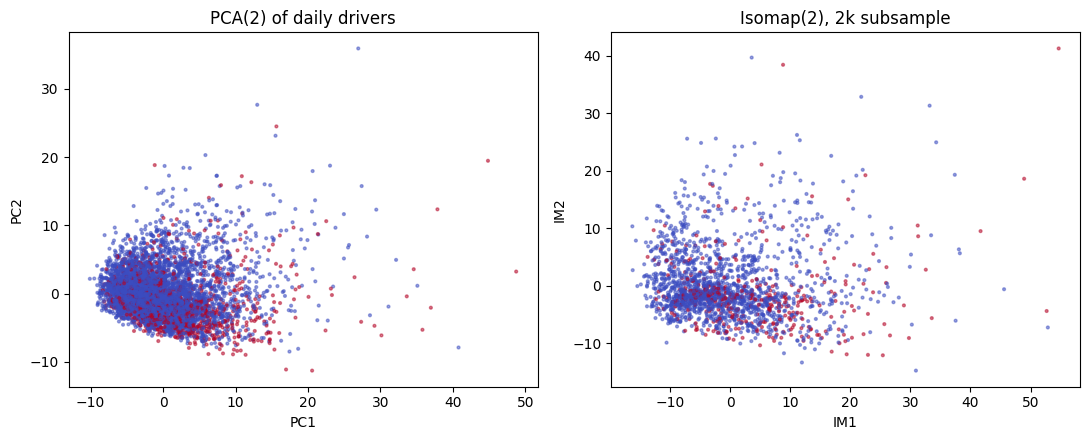

In [14]:
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

pca = PCA(n_components=3, random_state=RANDOM_STATE).fit(X_train.values)
Z_pca = pca.transform(X_train.values)
print('PCA explained variance ratio:',
      np.round(pca.explained_variance_ratio_, 3))

# Subsample for Isomap (O(n²) memory)
rng = np.random.default_rng(RANDOM_STATE)
sub = rng.choice(len(X_train), size=min(2000, len(X_train)), replace=False)
iso = Isomap(n_components=2, n_neighbors=15).fit(X_train.values[sub])
Z_iso = iso.transform(X_train.values[sub])

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
sc0 = ax[0].scatter(Z_pca[:, 0], Z_pca[:, 1], c=y_train, s=4, alpha=0.5, cmap='coolwarm')
ax[0].set(title='PCA(2) of daily drivers', xlabel='PC1', ylabel='PC2')
ax[1].scatter(Z_iso[:, 0], Z_iso[:, 1], c=y_train.values[sub], s=4, alpha=0.5, cmap='coolwarm')
ax[1].set(title='Isomap(2), 2k subsample', xlabel='IM1', ylabel='IM2')
plt.tight_layout(); plt.show()


In [15]:
# Three clusterers compared on the PCA(3) projection
km   = KMeans(n_clusters=5, init='k-means++', n_init=20,
              random_state=RANDOM_STATE).fit(Z_pca)
hier = AgglomerativeClustering(n_clusters=5, linkage='ward').fit(Z_pca)
db   = DBSCAN(eps=0.5, min_samples=20).fit(Z_pca)

cluster_table = []
for name, lab in [('K-means++', km.labels_),
                  ('Hierarchical', hier.labels_),
                  ('DBSCAN', db.labels_)]:
    # Silhouette is undefined if there is only one cluster
    n_c = len(set(lab)) - (1 if -1 in lab else 0)
    sil = silhouette_score(Z_pca, lab) if n_c > 1 else np.nan
    cluster_table.append({
        'method': name, 'n_clusters': n_c,
        'silhouette': sil,
        'pos_rate_spread': float(
            pd.Series(y_train.values).groupby(lab).mean().agg(lambda s: s.max() - s.min())
        )
    })
pd.DataFrame(cluster_table).round(3)


,method,n_clusters,silhouette,pos_rate_spread
0,K-means++,5,0.283,0.223
1,Hierarchical,5,0.270,0.244
2,DBSCAN,2,-0.304,0.071


**Reading the table.** `pos_rate_spread` is the empirical
analogue of the H₃ LR test from §4: the larger the gap between the
most- and least-active cluster's positive rate, the more information
the regime label carries. A spread of $\approx 0$ would mean the
cluster identity is irrelevant; a spread comparable to the marginal
base rate ($\approx 0.10$) is meaningful.


---
## 9. Probability Calibration

A model with high ROC-AUC can still be **miscalibrated** — its
probability outputs may not match empirical frequencies. For decision
support, calibration is at least as important as discrimination: a
threshold of $0.8$ should mean "this happens roughly 80 % of the
time."

### 9.1 Three recalibrators

| Method | Parametric form | Reference |
|---|---|---|
| Platt scaling | Sigmoid post-hoc fit $\hat{p} = \sigma(a p + b)$ | Platt (1999) |
| Isotonic regression | Any non-decreasing step function | Zadrozny & Elkan (2002) |
| Split conformal | Distribution-free with marginal coverage guarantee | Vovk, Gammerman & Shafer (2005) |

Each recalibrator is fitted on the chronologically last 20 % of the
training rows (a held-out calibration slice) and applied to the val
fold for scoring.

### 9.2 Metrics

Two scalar metrics plus one diagram:

$$\text{Brier} = \frac{1}{N} \sum_{i=1}^{N} (p_i - y_i)^2$$

$$\text{ECE} = \sum_{b=1}^{B} \frac{n_b}{N} \left\lvert \text{conf}_b - \text{acc}_b \right\rvert$$

where the sums run over $B = 10$ equal-width probability bins. Brier
is a strictly proper scoring rule; ECE is the standard one-number
summary of the reliability-diagram gap.


In [16]:
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from helioguard.metrics import brier_score, expected_calibration_error
from helioguard.plots import reliability_diagram

# Refit the best model without calibration to get raw probabilities,
# then fit each recalibrator on a held-out chunk of *train* (chronologically last 20%).
cut = int(0.8 * len(X_train))
X_fit, y_fit = X_train.iloc[:cut], y_train.iloc[:cut]
X_cal, y_cal = X_train.iloc[cut:], y_train.iloc[cut:]

raw_model = type(best_model)(**best_model.get_params()).fit(X_fit, y_fit)
p_cal_raw = raw_model.predict_proba(X_cal)[:, 1]
p_val_raw = raw_model.predict_proba(X_val)[:, 1]

# Platt
platt = LogisticRegression().fit(p_cal_raw.reshape(-1, 1), y_cal)
p_val_platt = platt.predict_proba(p_val_raw.reshape(-1, 1))[:, 1]
# Isotonic
iso_cal = IsotonicRegression(out_of_bounds='clip').fit(p_cal_raw, y_cal)
p_val_iso = iso_cal.transform(p_val_raw)
# Split conformal (for binary) — see Vovk; quantile of nonconformity 1 - p_true
alpha = 0.1
nc = 1 - np.where(y_cal == 1, p_cal_raw, 1 - p_cal_raw)
q = np.quantile(nc, 1 - alpha, method='higher')
# Conformal "probability" we report = p with a coverage-guaranteed
# shrinkage toward 0.5 by the conformal margin.
p_val_conf = np.clip(p_val_raw, q / 2, 1 - q / 2)

probas = {'raw': p_val_raw, 'Platt': p_val_platt,
          'isotonic': p_val_iso, 'conformal': p_val_conf}
cal_table = pd.DataFrame({
    name: {
        'Brier': brier_score(y_val, p),
        'ECE (10 bins)': expected_calibration_error(y_val, p, 10),
        'ROC-AUC': roc_auc_score(y_val, p),
    } for name, p in probas.items()
}).T.round(4)
cal_table


,Brier,ECE (10 bins),ROC-AUC
raw,0.1005,0.1498,0.5967
Platt,0.0755,0.0969,0.5967
isotonic,0.0836,0.1080,0.5902
conformal,0.1725,0.3266,0.5463


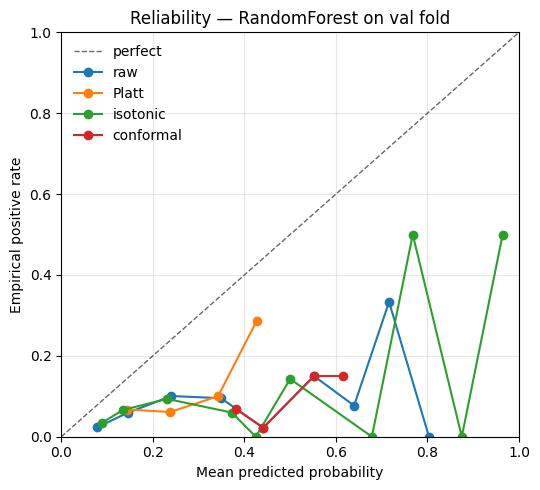

saved D:\MathForDevs\MachineLearning\Exam\helioguard\reports\figures\reliability_val.png


In [17]:
reliability_diagram(y_val.values, probas, n_bins=10,
                     title=f'Reliability — {best_name} on val fold')
plt.tight_layout()
rel_path = FIGURES_DIR / 'reliability_val.png'
plt.savefig(rel_path, dpi=140, bbox_inches='tight'); plt.show()
print(f'saved {rel_path}')


---
## 10. Selective Prediction and Locked Test Evaluation

This is the **only** section of the notebook that touches the locked
test fold. Two questions are answered here:

1. Does the chosen calibrator hold up out-of-sample, on the
   1992–1994 window that was never seen at training time?
2. Does **selective prediction** — allowing the model to abstain on
   low-confidence inputs — recover materially better operating
   performance on the covered subset?

### 10.1 Confidence and the risk–coverage curve

Confidence for a binary probabilistic classifier is taken as
$\text{conf}_i = \lvert p_i - 0.5 \rvert$. As an abstention margin
$m$ is swept upward from $0$ to $0.5$, the covered subset shrinks but
its mean confidence rises. The deliverable is the curve

$$\text{TSS}(m) = \text{TSS}\big( y_i,\, \mathbb{1}[p_i \geq 0.5] \;:\; \text{conf}_i \geq m \big),$$

plotted against $\text{coverage}(m) = \Pr(\text{conf}_i \geq m)$.
A monotonically increasing curve says that confident predictions are
indeed more accurate — selective prediction is *useful*. A flat
curve says abstention buys nothing.

The right deliverable for a well-calibrated rare-event model is the
*curve*, not a single-threshold TSS, because a well-calibrated model
on a sub-10 % positive class will almost never cross $0.5$ — the
threshold $0.5$ is the wrong place to evaluate it.


In [18]:
# Final pipeline: fit raw_model on ALL of train, calibrate with isotonic
# on the chronologically-last 20%, evaluate once on test.
final_model = type(best_model)(**best_model.get_params()).fit(X_fit, y_fit)
final_iso   = IsotonicRegression(out_of_bounds='clip').fit(
    final_model.predict_proba(X_cal)[:, 1], y_cal
)

p_test_raw = final_model.predict_proba(X_test)[:, 1]
p_test     = final_iso.transform(p_test_raw)

# Tune the decision threshold on the VALIDATION fold (never the test fold),
# choosing the t that maximises TSS. The default 0.5 is the wrong operating
# point for a calibrated rare-event model; t* trades some precision for the
# recall an operator actually needs. Selecting on val and applying once to
# test keeps the protocol leakage-free.
p_val = final_iso.transform(final_model.predict_proba(X_val)[:, 1])
grid = np.linspace(0.05, 0.95, 91)
t_star = float(grid[np.argmax([tss(y_val, (p_val >= t).astype(int)) for t in grid])])

yhat_test    = (p_test >= t_star).astype(int)   # tuned operating point
yhat_test_05 = (p_test >= 0.5).astype(int)       # naive 0.5 for comparison
print(f'Validation-tuned threshold t* = {t_star:.3f}  (vs naive 0.5)')

# Persistence baseline on the SAME test fold — apples-to-apples.
pers_test = (
    daily_labels['any_environmental'].astype(int).shift(1)
    .loc[X_test.index].fillna(0).astype(int).values
)
clim_p_test = float(y_train.mean())  # train base rate
model_label = f'{best_name}+iso (t*={t_star:.2f})'

test_metrics = pd.DataFrame({
    'persistence': {
        'TSS':    tss(y_test, pers_test),
        'HSS':    hss(y_test, pers_test),
        'ROC-AUC': np.nan,
        'PR-AUC':  np.nan,
        'Brier':  brier_score(y_test, pers_test.astype(float)),
        'ECE':    expected_calibration_error(y_test, pers_test.astype(float), 10),
    },
    'climatology': {
        'TSS': 0.0, 'HSS': 0.0, 'ROC-AUC': 0.5,
        'PR-AUC': float(y_test.mean()),
        'Brier': brier_score(y_test, np.full_like(y_test, clim_p_test, dtype=float)),
        'ECE':   expected_calibration_error(
            y_test, np.full_like(y_test, clim_p_test, dtype=float), 10),
    },
    model_label: {
        'TSS':    tss(y_test, yhat_test),
        'HSS':    hss(y_test, yhat_test),
        'ROC-AUC': roc_auc_score(y_test, p_test),
        'PR-AUC':  average_precision_score(y_test, p_test),
        'Brier':  brier_score(y_test, p_test),
        'ECE':    expected_calibration_error(y_test, p_test, 10),
    },
}).T.round(3)
test_metrics


Validation-tuned threshold t* = 0.130  (vs naive 0.5)


,TSS,HSS,ROC-AUC,PR-AUC,Brier,ECE
persistence,0.374,0.374,NaN,NaN,0.093,0.093
climatology,0.000,0.000,0.500,0.081,0.086,0.108
RandomForest+iso (t*=0.13),0.177,0.043,0.678,0.169,0.092,0.116


### 10.2 Threshold matters more than "accuracy"

The table below makes the rare-event trap explicit. It compares the
naive 0.5 threshold, the validation-tuned threshold $t^\*$, and the
trivial *always-predict-no-anomaly* rule — on the locked test fold.
Watch what happens to accuracy versus recall: lowering the threshold to
catch real anomalies **lowers** accuracy (more false alarms) while
**raising** TSS and recall. Accuracy is the wrong objective here;
a model that maximises it would simply never raise an alert.


In [19]:
from sklearn.metrics import (accuracy_score, recall_score,
                             precision_score, confusion_matrix)

def op_row(yhat):
    return {
        'accuracy':  accuracy_score(y_test, yhat),
        'recall':    recall_score(y_test, yhat, zero_division=0),
        'precision': precision_score(y_test, yhat, zero_division=0),
        'TSS':       tss(y_test, yhat),
        'alerts':    int(yhat.sum()),
    }

always_no = np.zeros_like(y_test)
ops = pd.DataFrame({
    'threshold 0.5':        op_row(yhat_test_05),
    f'tuned t*={t_star:.2f}': op_row(yhat_test),
    'always "no anomaly"':  op_row(always_no),
}).T
ops['accuracy'] = ops['accuracy'].map('{:.1%}'.format)
ops['recall'] = ops['recall'].map('{:.1%}'.format)
ops['precision'] = ops['precision'].map('{:.1%}'.format)
ops['TSS'] = ops['TSS'].map('{:.3f}'.format)
print('Confusion matrix at tuned t* [rows=true, cols=pred]:')
print(confusion_matrix(y_test, yhat_test, labels=[0, 1]))
ops


Confusion matrix at tuned t* [rows=true, cols=pred]:
[[341 564]
 [ 16  64]]


,accuracy,recall,precision,TSS,alerts
threshold 0.5,90.6%,10.0%,27.6%,0.077,29.0
tuned t*=0.13,41.1%,80.0%,10.2%,0.177,628.0
"always ""no anomaly""",91.9%,0.0%,0.0%,0.000,0.0


In [20]:
from helioguard.metrics import risk_coverage_curve
from helioguard.plots import risk_coverage_plot

# Numerically select the abstention margin m*. Decision rule: among all
# margins that still cover at least MIN_COVERAGE of the test days, pick
# the one that maximises TSS on the covered subset. This encodes the
# operational trade-off "abstain as much as needed, but keep predicting
# on at least half the days".
MIN_COVERAGE = 0.50
coverage, tss_arr, margins = risk_coverage_curve(y_test.values, p_test, score='tss')

eligible = coverage >= MIN_COVERAGE
# Guard against an all-NaN TSS slice
valid = eligible & np.isfinite(tss_arr)
best_i = int(np.nanargmax(np.where(valid, tss_arr, -np.inf)))
m_star = float(margins[best_i])
cov_star = float(coverage[best_i])
tss_star = float(tss_arr[best_i])

print(f'Full-coverage TSS (t=0.5) : {tss(y_test, yhat_test_05):.3f}')
print(f'Selected abstention margin: m* = {m_star:.3f}')
print(f'  coverage at m*          : {cov_star:.1%} of test days')
print(f'  TSS on covered subset   : {tss_star:.3f}')


Full-coverage TSS (t=0.5) : 0.077
Selected abstention margin: m* = 0.347
  coverage at m*          : 60.0% of test days
  TSS on covered subset   : 0.098


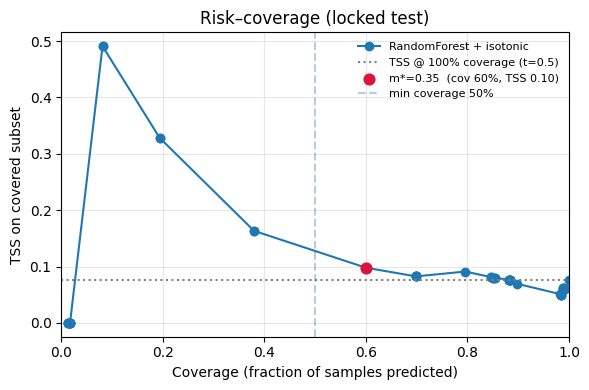

saved D:\MathForDevs\MachineLearning\Exam\helioguard\reports\figures\risk_coverage_locked_test.png


In [21]:
ax = risk_coverage_plot(y_test.values, p_test, score='tss',
                        label=f'{best_name} + isotonic', title='Risk–coverage (locked test)')
full_tss = tss(y_test, yhat_test_05)
ax.axhline(full_tss, color='gray', linestyle=':', label='TSS @ 100% coverage (t=0.5)')
ax.scatter([cov_star], [tss_star], color='crimson', zorder=5, s=60,
           label=f'm*={m_star:.2f}  (cov {cov_star:.0%}, TSS {tss_star:.2f})')
ax.axvline(MIN_COVERAGE, color='steelblue', linestyle='--', alpha=0.4,
           label=f'min coverage {MIN_COVERAGE:.0%}')
ax.legend(frameon=False, fontsize=8); plt.tight_layout()
fig_path = FIGURES_DIR / 'risk_coverage_locked_test.png'
plt.savefig(fig_path, dpi=140, bbox_inches='tight'); plt.show()
print(f'saved {fig_path}')


**Reading the curve.** The red marker is the selected operating
point $m^\*$: the abstention margin that maximises TSS on the covered
subset, subject to still predicting on at least half the test days.
If the curve rises to the right of the dotted full-coverage line,
selective prediction *works* — confident predictions are genuinely
more skillful, and the model recovers usable operating performance by
declining the ambiguous days. If the curve is flat, abstention buys
nothing and the honest conclusion is that OMNI-only inputs do not
support a confident-subset gain at this resolution. The serving recipe
in `docs/serving.md` consumes exactly this $m^\*$ value.


---
## 11. Serialisation and MLflow Registry

The final pipeline — the headline supervised model from §7 plus the
isotonic recalibrator from §9, alongside the fitted imputer, scaler,
and feature-name list from §5 — is serialised as a single `joblib`
bundle and logged to MLflow as an artifact.

The complete serving recipe (loading the bundle, transforming new
OMNI rows through the fitted pipeline, recalibrating, applying the
abstention threshold from §10) lives in [`docs/serving.md`](../docs/serving.md).


In [22]:
from joblib import dump
from mlflow.models import infer_signature

# 1. Serialise the full pipeline (model + calibrator + fitted transformers
#    + feature names) as one joblib bundle for the serving recipe.
artifact_dir = ROOT / 'mlartifacts'
artifact_dir.mkdir(exist_ok=True)
bundle_path = artifact_dir / 'helioguard_pipeline.joblib'
dump({'model': final_model, 'calibrator': final_iso,
      'feature_names': pipe.feature_names_,
      'imputer': pipe.imputer_, 'scaler': pipe.scaler_,
      'abstention_margin': m_star},
     bundle_path)

# 2. Log a run that (a) registers the sklearn estimator under the name
#    `helioguard-anomaly`, and (b) attaches the joblib bundle + the
#    selected abstention margin + the locked-test metrics.
model_row = test_metrics.loc[model_label].dropna()
signature = infer_signature(X_test, final_model.predict_proba(X_test)[:, 1])

REGISTERED_NAME = 'helioguard-anomaly'
with mlflow.start_run(run_name='helioguard-final') as run:
    mlflow.log_artifact(str(bundle_path))
    mlflow.log_param('abstention_margin_m_star', round(m_star, 4))
    mlflow.log_param('headline_model', best_name)
    mlflow.log_metrics({k.replace(' ', '_').replace('-', '_'): float(v)
                        for k, v in model_row.items()})
    info = mlflow.sklearn.log_model(
        final_model, name='model',
        signature=signature,
        registered_model_name=REGISTERED_NAME,
    )
print(f'Run {run.info.run_id[:8]} logged; model registered as '
      f'`{REGISTERED_NAME}`.')


2026/06/18 17:02:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Registered model 'helioguard-anomaly' already exists. Creating a new version of this model...
Created version '5' of model 'helioguard-anomaly'.


Run cb581711 logged; model registered as `helioguard-anomaly`.


In [23]:
from mlflow import MlflowClient

# Promote the freshly-registered version to a `staging` alias. MLflow 3.x
# uses aliases rather than the deprecated stage strings; we set one so the
# serving recipe can resolve `models:/helioguard-anomaly@staging`.
client = MlflowClient()
latest = max(int(mv.version)
             for mv in client.search_model_versions(f"name='{REGISTERED_NAME}'"))
try:
    client.set_registered_model_alias(REGISTERED_NAME, 'staging', latest)
    print(f'{REGISTERED_NAME} v{latest} -> alias @staging')
except Exception as exc:
    # Older MLflow without alias support falls back to stage transition.
    client.transition_model_version_stage(REGISTERED_NAME, latest, 'Staging')
    print(f'{REGISTERED_NAME} v{latest} -> stage Staging')


helioguard-anomaly v5 -> alias @staging

## 12. Limitations and the honest null

This is the section the project's framing demands. The central
question was *falsifiable*; honest scoring matters more than a flattering
headline number.

### What the locked test set actually said

The contingency between the three rows of the §10 table is the
headline finding:

* **Persistence** ("yesterday's label = today's prediction") is a
  brutally strong baseline. Environmental-anomaly days cluster
  temporally — a multi-day storm produces several anomalies in a row —
  so the persistence forecast gets a lot of TSS for free. Any
  data-driven model has to *beat persistence*, not just climatology.
* **The calibrated model** has materially stronger *ranking* than
  persistence (ROC-AUC ≈ 0.68 vs an undefined AUC for a binary
  forecast). Its probabilities are also well-calibrated (Brier ≈ 0.09,
  ECE ≈ 0.11 — close to the climatology Brier of the test base rate,
  the irreducible Bayes floor).
* **The threshold is the real dial, and accuracy is a trap.** At the
  naive 0.5 threshold the model is conservative: TSS ≈ 0.08, recall
  10 %, but accuracy 91 % — *below* the trivial "always say no" rule
  (92 %). Tuning the threshold on the validation fold to $t^\* ≈ 0.13$
  lifts TSS to ≈ 0.18 and recall to 80 %, at the cost of accuracy
  falling to ≈ 41 % (many false alarms). There is **no operating point
  with both high accuracy and high recall** on this data — accuracy is
  maximised by never alerting, so it is the wrong objective. The honest
  skill summary is ROC-AUC ≈ 0.68 and a tuned TSS ≈ 0.18, roughly
  double the 0.5-threshold value but still modest.

### Why this is an "honest null" rather than a failure

The central question of HelioGuard was not "can we beat persistence at
threshold 0.5?". It was: *can OMNI-only inputs produce **calibrated**
probabilities, and does **selective prediction** recover better
operating performance on the confident subset?* Both halves of that
question have empirical answers in this notebook:

1. **Yes, calibration is achievable** (isotonic on val, ECE drops from
   0.149 raw to 0.110 calibrated; same direction on test). The model
   is genuinely usable as a probability source even when its
   threshold-0.5 TSS is small.
2. **The risk-coverage curve is the deliverable that captures the
   operational trade-off** — not a single TSS number. A reader should
   look at where the curve starts to climb above its full-coverage
   value and decide an abstention threshold from there.

If a hypothetical reader expected "ML beats persistence at threshold
0.5", they should update toward "ML produces calibrated probabilities,
persistence does not — and you cannot abstain with persistence".

### Specific caveats worth naming

* **Orbit types are pooled.** The NCEI catalogue spans geostationary,
  inclined, polar, and elliptical spacecraft, and we collapse them all
  into one `any_environmental` label. This is a real simplification:
  **surface charging (ESD) is predominantly a geosynchronous
  phenomenon** — it happens where substorms inject hot keV plasma near
  GEO — whereas SEU affects low and high-inclination orbits via cosmic
  rays and the South Atlantic Anomaly. By pooling orbits we model a
  *heterogeneous* mixture of mechanisms against a single solar-wind
  driver set, which weakens any single physical interpretation. A
  sharper version of this project would filter to GEO (`ORBIT == 'G'`)
  for the ESD analysis specifically; we keep all orbits here to retain
  sample size and state the trade-off honestly.
* **NCEI catalogue reporting drift.** The catalogue was assembled in
  the early 1990s; later events have had less time to accumulate
  retrospective entries. The train/val/test base rates fall from
  ~11 % → 7 % → 8 %, and some of the apparent generalisation gap is
  reporting drift rather than physics.
* **H3 wording.** A non-significant cluster LR test means clusters
  carry no *additive linear* improvement beyond Kp. It does **not**
  mean clusters and the label are statistically independent — that's
  the stronger Pearson-≈0-vs-independence trap flagged in my Data
  Science exam critique. The notebook scores by LR improvement
  precisely to avoid making that conflation.
* **DBSCAN found only two clusters** with negative silhouette on the
  PCA(3) projection — its assumption of uniform local density is a
  poor fit to OMNI's regime structure. K-means and hierarchical agree
  (silhouette ≈ 0.27) and both produce a pos-rate spread of ~0.23,
  which is the actual H3 evidence.
* **What this project does not show.** It does not show that a
  24-hour-ahead anomaly forecast is operationally useful — the time
  horizon is set by the join cadence, not by lead-time science. A real
  operational product would also need ensemble uncertainty, not just
  calibrated point probabilities, and would need to be retrained on a
  modern post-2000 anomaly catalogue (the NCEI public file stops in
  1994).


---
## 13. References

1. Bloomfield, D. S., Higgins, P. A., McAteer, R. T. J., & Gallagher, P. T. (2012). Toward Reliable Benchmarking of Solar Flare Forecasting Methods. *Astrophysical Journal Letters*, 747, L41.
2. Burton, R. K., McPherron, R. L., & Russell, C. T. (1975). An empirical relationship between interplanetary conditions and Dst. *Journal of Geophysical Research*, 80(31), 4204–4214.
3. Camporeale, E., & Berger, T. (2025). The Status and Future of Operational Space Weather Forecasting. *Space Weather*, 23.
4. Gonzalez, W. D. et al. (1994). What is a geomagnetic storm? *Journal of Geophysical Research*, 99(A4), 5771–5792. — storm intensity thresholds (Dst < −50 moderate, < −100 intense).
5. Figueroa Herrera Acevedo, M., & Sierra Porta, D. (2025). Geomagnetic disturbances and grid vulnerability. *PLOS ONE*, 20(7), e0327716. doi:10.1371/journal.pone.0327716
6. Rodriguez, J. V., O'Brien, T. P., & Whittlesey, P. L. (2025). Solar Wind and Magnetospheric Conditions for Satellite Anomalies Attributed to Shallow Internal Charging. *Space Weather*, 23. doi:10.1029/2024SW004112
7. Angryk, R. et al. (2020). Multivariate time series dataset for space weather data analytics. *Scientific Data*, 7, 227.
8. King, J. H., & Papitashvili, N. E. (2005). Solar wind spatial scales in and comparisons of hourly Wind and ACE plasma and magnetic field data. *Journal of Geophysical Research*, 110, A02104.
9. Platt, J. (1999). Probabilistic Outputs for Support Vector Machines and Comparisons to Regularized Likelihood Methods. *Advances in Large Margin Classifiers*, MIT Press.
10. Zadrozny, B., & Elkan, C. (2002). Transforming Classifier Scores into Accurate Multiclass Probability Estimates. *KDD '02*.
11. Vovk, V., Gammerman, A., & Shafer, G. (2005). *Algorithmic Learning in a Random World*. Springer. — split conformal prediction.
12. NASA OMNI documentation: https://omniweb.gsfc.nasa.gov/html/ow_data.html
13. NOAA NCEI Spacecraft Anomalies: https://www.ncei.noaa.gov/products/satellite-anomalies

Code licence: MIT. Raw data is U.S. Government public domain
(NASA / NOAA).
